# V-Beam Thermal Sensor — Inverse Design via Gradient Descent

Set **`MODEL_TYPE`** in section 4 to choose between the MLP and PINN forward models.  
Both model classes are defined here so the chosen one can be instantiated from its saved checkpoint.

**Workflow:**
1. Load data + model class definitions
2. Select `MODEL_TYPE` and load the saved model + scalers from `../Models/`
3. Reconstruct the matching test split
4. Run gradient descent inverse design
5. Evaluate, save, and plot results

> Prerequisites: run `MLP-train.ipynb` and/or `PhInf-train.ipynb` first.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA GPU not found. Install CUDA-enabled PyTorch: "
        "https://pytorch.org/get-started/locally/"
    )
device = torch.device("cuda")
torch.backends.cudnn.benchmark = True
print(f"Using GPU : {torch.cuda.get_device_name(0)}")
print(f"VRAM      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using GPU : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM      : 8.6 GB


## 2. Load Data

In [2]:
EXCEL_PATH = "../Data/Datasets/Dataset_mare_5.11.2025.xlsx"

df = pd.read_excel(EXCEL_PATH)

INPUT_COLS  = ["Beta Angle", "Beam Length", "Beam Width",
               "Delta Temp", "Young's Modulus - E", "CTE - alpha"]
OUTPUT_COLS = ["Sensor Displacement", "Max Mechanical Stress", "Vol"]

df_clean = df[INPUT_COLS + OUTPUT_COLS].dropna()
print(f"Dataset loaded: {len(df_clean)} rows")

Dataset loaded: 3000 rows


## 3. Model Class Definitions

Both classes are defined so the correct one can be instantiated based on `MODEL_TYPE`.

In [3]:
class MLPForwardNet(nn.Module):
    def __init__(self, in_dim=6, out_dim=3, hidden_sizes=(128, 128), dropout=0.1):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class PINNForwardNet(nn.Module):
    def __init__(self, in_dim=6, out_dim=3, hidden_sizes=(128, 128), dropout=0.1):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## 4. Select Model Type and Load Checkpoint

Change `MODEL_TYPE` to `"MLP"` or `"PINN"` before running.

In [4]:
MODEL_TYPE = "PINN"   

if MODEL_TYPE == "MLP":
    MODEL_PATH  = "../Models/mlp_forward_model.pt"
    SCALER_PATH = "../Models/mlp_scalers.pkl"
    ModelClass  = MLPForwardNet
elif MODEL_TYPE == "PINN":
    MODEL_PATH  = "../Models/pinn_forward_model.pt"
    SCALER_PATH = "../Models/pinn_scalers.pkl"
    ModelClass  = PINNForwardNet
else:
    raise ValueError(f"Unknown MODEL_TYPE: {MODEL_TYPE!r}. Use 'MLP' or 'PINN'.")

checkpoint = torch.load(MODEL_PATH, map_location=device, weights_only=False)
best_gs_params = checkpoint["best_params"]
INPUT_COLS     = checkpoint["input_cols"]
OUTPUT_COLS    = checkpoint["output_cols"]

scalers  = joblib.load(SCALER_PATH)
scaler_x = scalers["scaler_x"]
scaler_y = scalers["scaler_y"]

model = ModelClass(
    in_dim=len(INPUT_COLS), out_dim=len(OUTPUT_COLS),
    hidden_sizes=best_gs_params["hidden_sizes"],
    dropout=best_gs_params["dropout"]
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

for p in model.parameters():
    p.requires_grad_(False)

print(f"Loaded {MODEL_TYPE} model  : {best_gs_params}")
print(f"Input cols  : {INPUT_COLS}")
print(f"Output cols : {OUTPUT_COLS}")

Loaded PINN model  : {'hidden_sizes': (64, 64), 'dropout': 0.0, 'lr': 0.0005, 'batch_size': 128}
Input cols  : ['Beta Angle', 'Beam Length', 'Beam Width', 'Delta Temp', "Young's Modulus - E", 'CTE - alpha']
Output cols : ['Sensor Displacement', 'Max Mechanical Stress', 'Vol']


## 5. Reconstruct Test Split

In [5]:
test_indices = np.array(checkpoint["test_indices"])

X_raw = df_clean[INPUT_COLS].values.astype("float32")
Y_raw = df_clean[OUTPUT_COLS].values.astype("float32")

X_tensor = torch.from_numpy(scaler_x.transform(X_raw).astype("float32"))
Y_tensor = torch.from_numpy(scaler_y.transform(Y_raw).astype("float32"))

print(f"Test set size: {len(test_indices)}")

Test set size: 450


## 6. Geometry Bounds and Reference Values

In [6]:
BETA_MIN, BETA_MAX = 10.0, 40.0
L_MIN,    L_MAX    = 20.0, 35.0
W_MIN,    W_MAX    =  1.0,  2.0

STRESS_REF = float(df_clean["Max Mechanical Stress"].mean())
VOL_REF    = float(df_clean["Vol"].mean())
DISP_REF   = float(df_clean["Sensor Displacement"].std())

print(f"Reference stress: {STRESS_REF:.2f} MPa")
print(f"Reference vol   : {VOL_REF:.2f} mm³")
print(f"Displacement std: {DISP_REF:.5f} mm")

Reference stress: 69.93 MPa
Reference vol   : 627.74 mm³
Displacement std: 0.04219 mm


## 7. Inverse Design Function

Gradient flows through the **frozen** forward model to optimise `(β, L, w)`.  
Multiple random restarts; best result = lowest stress within `disp_tol`.

In [7]:
def inverse_design(
    target_disp,
    delta_temp,
    E             = 71000.0,
    alpha         = 23e-6,
    lambda_disp   = 1.0,
    lambda_stress = 0.001,
    lambda_vol    = 0.001,
    n_restarts    = 10,
    n_iter        = 2000,
    lr            = 0.05,
    disp_tol      = 0.005,
    verbose       = True,
):
    fixed_vals = np.array([delta_temp, E, alpha], dtype="float32")

    bounds_phys   = np.array([[BETA_MIN, L_MIN, W_MIN, delta_temp, E, alpha],
                               [BETA_MAX, L_MAX, W_MAX, delta_temp, E, alpha]], dtype="float32")
    bounds_scaled = scaler_x.transform(bounds_phys)
    geom_min = torch.tensor(bounds_scaled[0, :3], device=device)
    geom_max = torch.tensor(bounds_scaled[1, :3], device=device)

    target_disp_scaled = torch.tensor(
        float(scaler_y.transform([[target_disp, 0.0, 0.0]])[0, 0]), device=device)

    all_results = []
    for restart in range(n_restarts):
        geom_raw    = np.array([np.random.uniform(BETA_MIN, BETA_MAX),
                                 np.random.uniform(L_MIN, L_MAX),
                                 np.random.uniform(W_MIN, W_MAX)], dtype="float32")
        full_scaled = scaler_x.transform(np.concatenate([geom_raw, fixed_vals]).reshape(1, -1))[0]

        geom_scaled  = torch.tensor(full_scaled[:3], requires_grad=True, device=device)
        fixed_scaled = torch.tensor(full_scaled[3:], requires_grad=False, device=device)
        optim = torch.optim.Adam([geom_scaled], lr=lr)

        for _ in range(n_iter):
            optim.zero_grad()
            geom_c = torch.clamp(geom_scaled, geom_min, geom_max)
            y_pred = model(torch.cat([geom_c, fixed_scaled]).unsqueeze(0)).squeeze(0)
            loss   = (lambda_disp   * (y_pred[0] - target_disp_scaled) ** 2
                    + lambda_stress * y_pred[1]
                    + lambda_vol    * y_pred[2])
            loss.backward()
            optim.step()

        with torch.no_grad():
            geom_c   = torch.clamp(geom_scaled, geom_min, geom_max)
            x_in     = torch.cat([geom_c, fixed_scaled]).unsqueeze(0)
            y_pred_s = model(x_in).squeeze(0).cpu().numpy()
            x_in_cpu = x_in.cpu().numpy()

        y_phys   = scaler_y.inverse_transform(y_pred_s.reshape(1, -1))[0]
        x_phys   = scaler_x.inverse_transform(x_in_cpu)[0]
        disp_err = abs(y_phys[0] - target_disp)
        result   = dict(beta=float(x_phys[0]), beam_length=float(x_phys[1]),
                        beam_width=float(x_phys[2]), pred_displacement=float(y_phys[0]),
                        pred_stress=float(y_phys[1]), pred_vol=float(y_phys[2]),
                        disp_err=disp_err)
        all_results.append(result)
        if verbose:
            print(f"  Restart {restart+1:2d}: β={x_phys[0]:.2f}°  "
                  f"L={x_phys[1]:.2f}mm  w={x_phys[2]:.2f}mm  "
                  f"→ disp={y_phys[0]:.4f}mm  stress={y_phys[1]:.1f}MPa  vol={y_phys[2]:.1f}mm³")

    good = [r for r in all_results if r["disp_err"] <= disp_tol]
    if good:
        best = min(good, key=lambda r: r["pred_stress"])
        note = f"(min stress among {len(good)} restarts within {disp_tol*1000:.1f} µm)"
    else:
        best = min(all_results, key=lambda r: r["disp_err"])
        note = "(fallback: closest displacement)"

    if verbose:
        print()
        print("=" * 65)
        print(f"  TARGET displacement : {target_disp:.4f} mm")
        print(f"  {note}")
        print(f"  Best result:")
        print(f"    β           = {best['beta']:.3f} °")
        print(f"    Beam Length = {best['beam_length']:.3f} mm")
        print(f"    Beam Width  = {best['beam_width']:.3f} mm")
        print(f"    Pred disp   = {best['pred_displacement']:.4f} mm  "
              f"(error = {best['disp_err']/target_disp*100:.2f}%)")
        print(f"    Pred stress = {best['pred_stress']:.2f} MPa")
        print(f"    Pred vol    = {best['pred_vol']:.2f} mm³")
        print("=" * 65)
    return best

## 8. Evaluate on Test Samples

250 samples for MLP, 450 for PINN (matching the original evaluations).

In [8]:
X_test_phys = scaler_x.inverse_transform(X_tensor[test_indices].numpy())
Y_test_phys = scaler_y.inverse_transform(Y_tensor[test_indices].numpy())

N_EVAL = min(450, len(test_indices))
sample_idx = np.random.choice(len(test_indices), size=N_EVAL, replace=False)

rel_errors, records = [], []
print(f"Running inverse gradient descent on {N_EVAL} {MODEL_TYPE} test samples...")
print("-" * 70)

for i, idx in enumerate(sample_idx):
    target_disp = float(Y_test_phys[idx, 0])
    delta_temp  = float(X_test_phys[idx, 3])
    E_val       = float(X_test_phys[idx, 4])
    alpha_val   = float(X_test_phys[idx, 5])

    result    = inverse_design(target_disp=target_disp, delta_temp=delta_temp,
                               E=E_val, alpha=alpha_val,
                               n_restarts=5, n_iter=1000, verbose=False)
    pred_disp = result["pred_displacement"]
    rel_err   = (pred_disp - target_disp) / target_disp * 100
    rel_errors.append(rel_err)

    records.append({
        "Target Displacement [mm]" : target_disp,
        "Delta Temp [C]"           : delta_temp,
        "E [MPa]"                  : E_val,
        "Alpha [1/C]"              : alpha_val,
        "True Beta Angle [deg]"    : float(X_test_phys[idx, 0]),
        "True Beam Length [mm]"    : float(X_test_phys[idx, 1]),
        "True Beam Width [mm]"     : float(X_test_phys[idx, 2]),
        "Pred Beta Angle [deg]"    : result["beta"],
        "Pred Beam Length [mm]"    : result["beam_length"],
        "Pred Beam Width [mm]"     : result["beam_width"],
        "Pred Displacement [mm]"   : pred_disp,
        "Pred Stress [MPa]"        : result["pred_stress"],
        "Pred Volume [mm3]"        : result["pred_vol"],
        "Relative Error [%]"       : rel_err,
        "Absolute Error [mm]"      : result["disp_err"],
    })
    print(f"  [{i+1:3d}/{N_EVAL}]  target={target_disp:.4f}mm  pred={pred_disp:.4f}mm  rel_err={rel_err:+.2f}%")

rel_errors = np.array(rel_errors)
abs_rel    = np.abs(rel_errors)
print()
print("=" * 70)
print(f"  {MODEL_TYPE} Inverse Model — Gradient Test on {N_EVAL} samples")
print(f"  Mean Absolute Relative Error  : {abs_rel.mean():.3f} %")
print(f"  Median Absolute Relative Error: {np.median(abs_rel):.3f} %")
print(f"  Max  Absolute Relative Error  : {abs_rel.max():.3f} %")
print(f"  Samples within  1% error      : {(abs_rel <= 1.0).sum()} / {N_EVAL}")
print(f"  Samples within  5% error      : {(abs_rel <= 5.0).sum()} / {N_EVAL}")
print(f"  Samples within 10% error      : {(abs_rel <= 10.0).sum()} / {N_EVAL}")
print("=" * 70)

Running inverse gradient descent on 450 PINN test samples...
----------------------------------------------------------------------
  [  1/450]  target=0.0754mm  pred=0.0753mm  rel_err=-0.04%
  [  2/450]  target=0.0903mm  pred=0.0903mm  rel_err=-0.01%
  [  3/450]  target=0.1143mm  pred=0.1143mm  rel_err=-0.01%
  [  4/450]  target=0.0660mm  pred=0.0659mm  rel_err=-0.04%
  [  5/450]  target=0.1332mm  pred=0.1331mm  rel_err=-0.04%
  [  6/450]  target=0.0990mm  pred=0.0990mm  rel_err=-0.01%
  [  7/450]  target=0.0833mm  pred=0.0833mm  rel_err=-0.03%
  [  8/450]  target=0.0548mm  pred=0.0548mm  rel_err=-0.01%
  [  9/450]  target=0.0315mm  pred=0.0312mm  rel_err=-1.06%
  [ 10/450]  target=0.0705mm  pred=0.0704mm  rel_err=-0.02%
  [ 11/450]  target=0.1899mm  pred=0.1899mm  rel_err=-0.00%
  [ 12/450]  target=0.1351mm  pred=0.1351mm  rel_err=-0.00%
  [ 13/450]  target=0.1232mm  pred=0.1232mm  rel_err=-0.01%
  [ 14/450]  target=0.1124mm  pred=0.1124mm  rel_err=-0.00%
  [ 15/450]  target=0.1473mm

## 9. Save Results to Excel

In [9]:
RESULTS_DIR = "../Data/GD_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

df_results = pd.DataFrame(records)
out_path   = os.path.join(RESULTS_DIR, f"{MODEL_TYPE}_inverse_gradient_test_results.xlsx")
df_results.to_excel(out_path, index=False)
print(f"Results saved to: {out_path}")
print(f"  {len(df_results)} rows x {len(df_results.columns)} columns")

Results saved to: ../Data/GD_results\PINN_inverse_gradient_test_results.xlsx
  450 rows x 15 columns


## 10. Error Distribution Plots

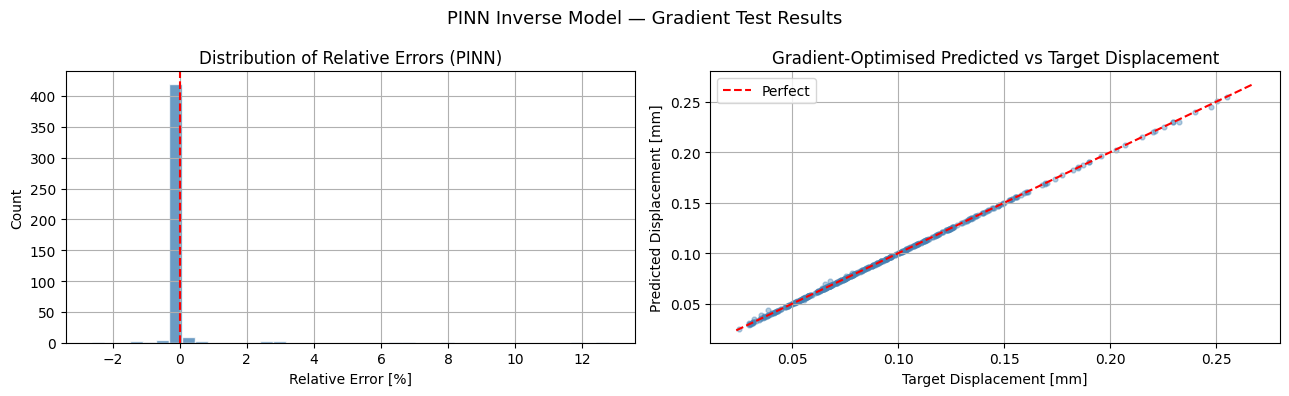

In [10]:
color = "darkorange" if MODEL_TYPE == "MLP" else "steelblue"

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(rel_errors, bins=40, color=color, edgecolor="white", alpha=0.8)
ax.axvline(0, color="red", lw=1.5, linestyle="--")
ax.set_xlabel("Relative Error [%]"); ax.set_ylabel("Count")
ax.set_title(f"Distribution of Relative Errors ({MODEL_TYPE})"); ax.grid(True)

ax = axes[1]
targets_arr = np.array([r["Target Displacement [mm]"] for r in records])
preds_arr   = np.array([r["Pred Displacement [mm]"]   for r in records])
ax.scatter(targets_arr, preds_arr, alpha=0.4, s=12, color=color)
lims = [targets_arr.min() * 0.95, targets_arr.max() * 1.05]
ax.plot(lims, lims, "r--", lw=1.5, label="Perfect")
ax.set_xlabel("Target Displacement [mm]"); ax.set_ylabel("Predicted Displacement [mm]")
ax.set_title("Gradient-Optimised Predicted vs Target Displacement")
ax.legend(); ax.grid(True)

plt.suptitle(f"{MODEL_TYPE} Inverse Model — Gradient Test Results", fontsize=13)
plt.tight_layout(); plt.show()

## 11. Example Single Query

In [11]:
result_example = inverse_design(
    target_disp   = 0.10,
    delta_temp    = 45.0,
    lambda_disp   = 1.0,
    lambda_stress = 0.001,
    lambda_vol    = 0.001,
    n_restarts    = 10,
    n_iter        = 2000,
    verbose       = True,
)

  Restart  1: β=13.91°  L=20.00mm  w=1.00mm  → disp=0.0998mm  stress=65.0MPa  vol=487.4mm³
  Restart  2: β=17.84°  L=28.42mm  w=1.00mm  → disp=0.1000mm  stress=61.9MPa  vol=546.9mm³
  Restart  3: β=13.87°  L=20.00mm  w=1.00mm  → disp=0.1000mm  stress=65.0MPa  vol=487.4mm³
  Restart  4: β=17.08°  L=27.51mm  w=1.00mm  → disp=0.1000mm  stress=63.0MPa  vol=543.6mm³
  Restart  5: β=16.51°  L=24.80mm  w=1.00mm  → disp=0.1000mm  stress=65.0MPa  vol=529.3mm³
  Restart  6: β=17.81°  L=28.38mm  w=1.00mm  → disp=0.1000mm  stress=61.9MPa  vol=546.8mm³
  Restart  7: β=13.87°  L=20.00mm  w=1.00mm  → disp=0.1000mm  stress=65.0MPa  vol=487.4mm³
  Restart  8: β=13.95°  L=20.09mm  w=1.00mm  → disp=0.1000mm  stress=64.9MPa  vol=488.2mm³
  Restart  9: β=20.00°  L=31.28mm  w=1.00mm  → disp=0.1000mm  stress=60.7MPa  vol=561.8mm³
  Restart 10: β=13.87°  L=20.00mm  w=1.00mm  → disp=0.1000mm  stress=65.0MPa  vol=487.4mm³

  TARGET displacement : 0.1000 mm
  (min stress among 10 restarts within 5.0 µm)
  Best r